# Partie 2 : Analyse Exploratoire des Données (EDA)
Dans cette section, nous allons utiliser `Matplotlib` et `Seaborn` pour visualiser les relations entre nos différentes variables (features) et notre variable cible (Churn). L'objectif est d'identifier visuellement les facteurs qui poussent un client à la résiliation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style visuel pour des graphiques pro
sns.set_theme(style="whitegrid")
couleurs_churn = ["#4A90E2", "#F5A623"] # Bleu pour Non, Orange pour Oui

# Chargement des données depuis le CSV (plus direct pour Pandas)
df = pd.read_csv('../data/telco_churn.csv')

# Conversion de TotalCharges en numérique (gestion des erreurs)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Visualisation de la variable cible (Churn)
Commençons par visualiser le déséquilibre de nos classes.

/var/folders/83/vzd01t1d1yl2mfpjlysjlmmc0000gn/T/ipykernel_33741/4265652732.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=couleurs_churn)


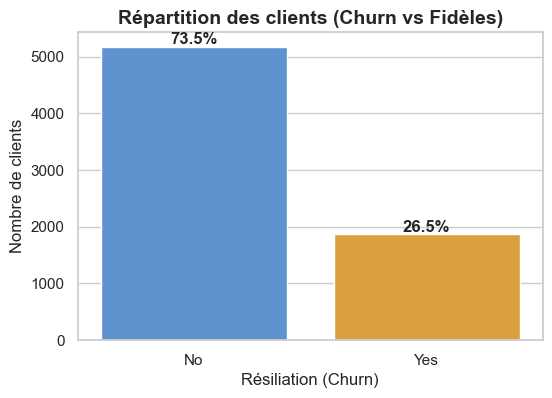

In [2]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette=couleurs_churn)
plt.title("Répartition des clients (Churn vs Fidèles)", fontsize=14, fontweight='bold')
plt.xlabel("Résiliation (Churn)")
plt.ylabel("Nombre de clients")

# Ajout des pourcentages sur les barres
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.show()

### 2. L'impact du prix et de l'ancienneté (KDE Plots)
Les requêtes SQL nous ont montré que les clients qui partent paient plus cher et restent moins longtemps. Visualisons la distribution de ces deux variables avec des courbes de densité.    

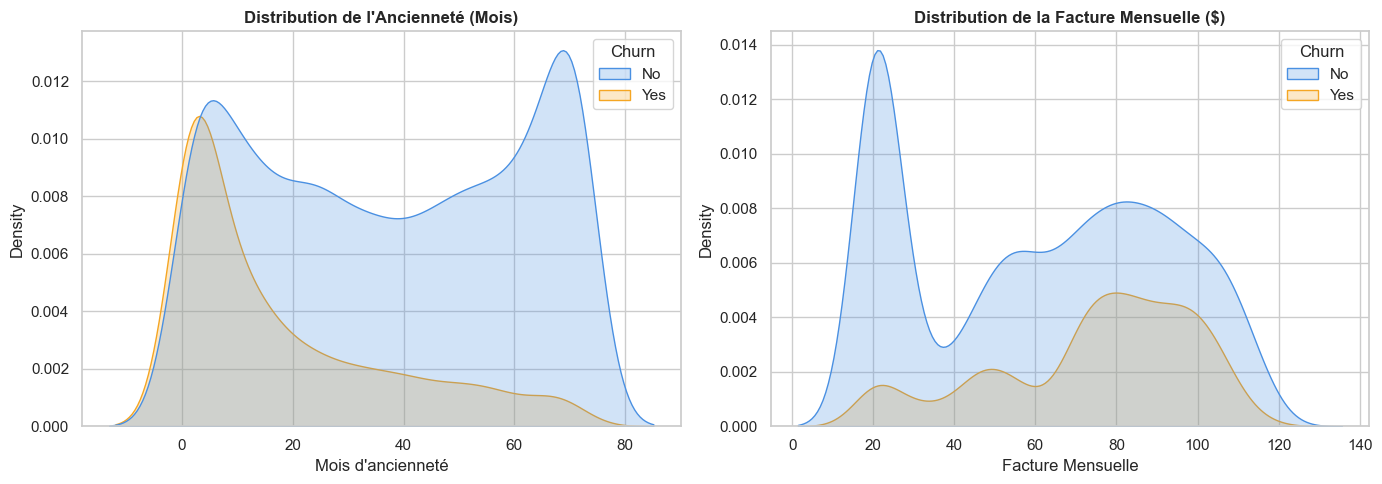

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Ancienneté (Tenure)
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, palette=couleurs_churn, ax=axes[0])
axes[0].set_title("Distribution de l'Ancienneté (Mois)", fontweight='bold')
axes[0].set_xlabel("Mois d'ancienneté")

# Graphique 2 : Facture Mensuelle (MonthlyCharges)
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, palette=couleurs_churn, ax=axes[1])
axes[1].set_title("Distribution de la Facture Mensuelle ($)", fontweight='bold')
axes[1].set_xlabel("Facture Mensuelle")

plt.tight_layout()
plt.show()

**Interprétation :**
* **Ancienneté (gauche) :** Le pic orange est énorme au tout début (0-5 mois). Le risque de perdre un client est critique durant ses premiers mois d'abonnement.
* **Prix (droite) :** Le pic orange se situe autour de 70-100$. Les factures élevées génèrent beaucoup d'insatisfaction (potentiellement liée à l'ajout de la Fibre Optique qui coûte plus cher).

### 3. Impact des services souscrits sur la rétention
Pour terminer cette exploration visuelle, regardons si certains services techniques spécifiques sont liés à un taux de départ plus élevé, notamment le type de connexion Internet et l'accès au support technique.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Type de connexion Internet
sns.countplot(data=df, x="InternetService", hue="Churn", palette=couleurs_churn, ax=axes[0])
axes[0].set_title("Churn par type de connexion Internet", fontweight='bold')
axes[0].set_xlabel("Service Internet")
axes[0].set_ylabel("Nombre de clients")

# Graphique 2 : Accès au Support Technique
sns.countplot(data=df, x="TechSupport", hue="Churn", palette=couleurs_churn, ax=axes[1])
axes[1].set_title("Churn selon l'accès au support technique", fontweight='bold')
axes[1].set_xlabel("Support Technique")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Conclusion de l'analyse exploratoire :**
* Les clients disposant de la Fibre Optique ("Fiber optic") présentent un taux de résiliation paradoxalement très élevé par rapport à l'ADSL ("DSL"). Cela suggère un problème de fiabilité du réseau fibre ou une tarification trop agressive.
* L'absence de support technique ("No") est un facteur de départ massif.
* Le profil type du client à risque est donc : un nouvel abonné, en contrat mensuel, avec la fibre optique mais sans support technique.

Ces observations métiers vont nous permettre de valider la pertinence de notre futur modèle de Machine Learning.